In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import matplotlib.patches as patches
from matplotlib.lines import Line2D

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [3]:
hydrogenResultsFileName = 'hydrogen_GWP_results_breakdown.xlsx'
ammoniaResultsFileName = 'ammonia_GWP_results_breakdown.xlsx'
methanolResultsFileName = 'methanol_GWP_results_breakdown.xlsx'
ethyleneResultsFileName = 'ethylene_GWP_results_breakdown.xlsx'

In [4]:
hydrogenBAUDF = pd.read_excel(os.path.join('..', 'Results', 'Hydrogen', hydrogenResultsFileName), sheet_name = 'hydrogenBAU', index_col = 0)
hydrogenSolarDF = pd.read_excel(os.path.join('..', 'Results', 'Hydrogen', hydrogenResultsFileName), sheet_name = 'hydrogenSolar', index_col = 0)
hydrogenWindDF = pd.read_excel(os.path.join('..', 'Results', 'Hydrogen', hydrogenResultsFileName), sheet_name = 'hydrogenWind', index_col = 0)

In [5]:
hydrogenDF = pd.concat([hydrogenBAUDF, hydrogenSolarDF, hydrogenWindDF])
hydrogenDF = hydrogenDF.fillna(0)
hydrogenImageRCP6DF = hydrogenDF[hydrogenDF['database'].str.contains('image SSP2-RCP6')]
hydrogenImageRCP26DF = hydrogenDF[hydrogenDF['database'].str.contains('image SSP2-RCP26') | hydrogenDF['database'].str.contains('image SSP2-RCP6 2020')]
hydrogenImageRCP19DF = hydrogenDF[hydrogenDF['database'].str.contains('image SSP2-RCP19') | hydrogenDF['database'].str.contains('image SSP2-RCP6 2020')]
hydrogenRemindRCP6DF = hydrogenDF[hydrogenDF['database'].str.contains('remind SSP2-RCP6') | hydrogenDF['database'].str.contains('image SSP2-RCP6 2020')]
hydrogenRemindRCP26DF = hydrogenDF[hydrogenDF['database'].str.contains('remind SSP2-RCP26') | hydrogenDF['database'].str.contains('image SSP2-RCP6 2020')]
hydrogenRemindRCP19DF = hydrogenDF[hydrogenDF['database'].str.contains('remind SSP2-RCP19') | hydrogenDF['database'].str.contains('image SSP2-RCP6 2020')]

In [27]:
def hydrogen_breakdown_plots(originalDF, ax):
    df_plot_new = pd.DataFrame()
    df_plot = originalDF.drop(['name', 'database'], axis = 1)
    columns_to_drop = [col for col in df_plot.columns if 'hydrogen' in col]
    df_plot = df_plot.drop(columns = columns_to_drop)

    df_plot_new['Natural gas'] = df_plot['market group for natural gas, high pressure']
    df_plot_new['Water'] = df_plot['market for water, deionised']
    df_plot_new['Electricity'] = df_plot['market group for electricity, high voltage']
    df_plot_new['Renewable electricity'] = df_plot['electricity production, photovoltaic, 570kWp open ground installation, multi-Si'] + df_plot['electricity production, wind, >3MW turbine, onshore']
    df_plot_new['Other utilities'] = df_plot['PEM electrolyser construction']
    df_plot_new['Direct emissions'] = df_plot['direct emissions']
    
    colors = ['#808080', '#167f99', '#fb7b71', '#a9d898', '#a78dd8', '#b71205']
    df_plot_new.plot(kind = 'bar', stacked = True, ax = ax, color = colors)

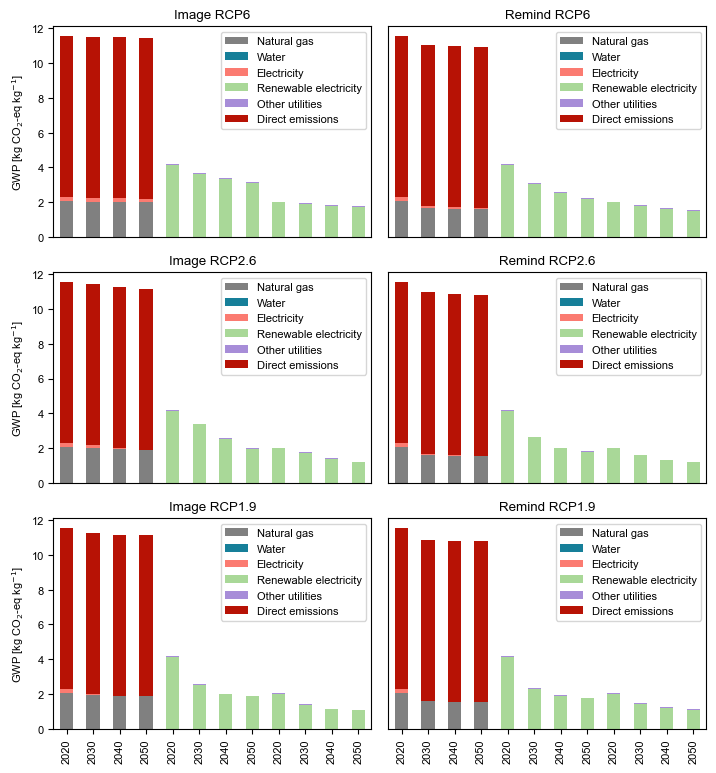

In [55]:
fig, ([ax1, ax4], [ax2, ax5], [ax3, ax6]) = plt.subplots(3, 2, figsize = (fig_length[2], fig_height*0.8))

hydrogen_breakdown_plots(hydrogenImageRCP6DF, ax1)
ax1.xaxis.set_ticks_position('none')
ax1.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax1.set_title('Image RCP6')
ax1.set_xticks([])

hydrogen_breakdown_plots(hydrogenImageRCP26DF, ax2)
ax2.xaxis.set_ticks_position('none')
ax2.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax2.set_title('Image RCP2.6')
ax2.set_xticks([])

hydrogen_breakdown_plots(hydrogenImageRCP19DF, ax3)
ax3.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax3.set_title('Image RCP1.9')
ax3.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])  
ax3.set_xticklabels(['2020', '2030', '2040', '2050']*3, rotation = 90)  

hydrogen_breakdown_plots(hydrogenRemindRCP6DF, ax4)
ax4.xaxis.set_ticks_position('none')
ax4.set_yticks([])
ax4.set_xticks([])
ax4.set_title('Remind RCP6')

hydrogen_breakdown_plots(hydrogenRemindRCP26DF, ax5)
ax5.xaxis.set_ticks_position('none')
ax5.set_yticks([])
ax5.set_xticks([])
ax5.set_title('Remind RCP2.6')

hydrogen_breakdown_plots(hydrogenRemindRCP19DF, ax6)
ax6.set_yticks([])
ax6.set_title('Remind RCP1.9')
ax6.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])  
ax6.set_xticklabels(['2020', '2030', '2040', '2050']*3, rotation = 90)  

plt.savefig('Hydrogen breakdown.png', format = 'png', bbox_inches = 'tight', dpi = 600)